# Predictive Maintenance — Turbofan Engine Health Classification

**Dataset**: NASA C-MAPSS (Commercial Modular Aero-Propulsion System Simulation)
**Source**: [Kaggle — behrad3d/nasa-cmaps](https://www.kaggle.com/datasets/behrad3d/nasa-cmaps)
**Task**: Binary health classification — *Healthy / Non-Healthy*
**Models**: FLAML AutoML (tabular rolling features) · LSTM (sensor time-series sequences)
**Processing**: Pandas-based feature engineering with operating-condition normalisation

---

The C-MAPSS dataset simulates turbofan engine degradation under varying operating conditions.
Four sub-datasets (FD001–FD004) differ in the number of operating regimes (1 or 6) and
fault modes (1 or 2).  Each row is one engine cycle with readings from 21 sensors.
The objective is to detect whether an engine is in a degraded health state from its
sensor history, enabling early intervention before catastrophic failure.

**Health-state encoding**
RUL (Remaining Useful Life) is derived from training run-to-failure data.
A single data-driven threshold separates the two classes:
- `Healthy (0)` : capped RUL > threshold (engine operating normally)
- `Non-Healthy (1)` : capped RUL ≤ threshold (degradation detected — maintenance warranted)

The threshold is selected via an ExtraTrees proxy grid-search on training data only
(default: RUL > 80 → Healthy).

In [23]:
# =========================================================
# 0. Imports & Configuration
# =========================================================

# --- Standard library ---
import importlib.util
import itertools
import sys
import warnings
from pathlib import Path

# --- Third-party core ---
import numpy as np
import pandas as pd

# --- Visualisation ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Scikit-learn ---
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import f1_score, make_scorer
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

# --- AutoML & experiment tracking ---
import mlflow
import mlflow.sklearn

# --- SHAP ---
import shap

# --- Project utils ---
def _load_module(name: str, rel_path: str):
    """Dynamically load a utility module by relative file path."""
    spec = importlib.util.spec_from_file_location(name, Path(rel_path))
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    sys.modules[name] = mod
    return mod

plot_style = _load_module("plot_style", "utils/plot_style.py")
from plot_style import (  # noqa: E402
    apply_style, FigSize,
    CMAP, C1, C2, C3,
    CMAP_DMG, D1, D2, D3,
    CMAP_IR,  I1, I2, I3,
    blues, salmons, greens,
)

from utils.download_dataset import get_data_dir
from utils.data_loader import (
    load_all_fds, compute_rul, attach_test_rul,
    USEFUL_SENSORS, OP_SETTINGS, CLASS_NAMES,
)
from utils.feature_engineering import (
    add_rolling_features_spark,
    add_long_window_features,
    min_max_normalise_spark, apply_min_max_spark,
    fit_condition_normaliser, apply_condition_normaliser,
    create_lstm_sequences, get_feature_cols,
)
from utils.ml_classification import (
    run_automl_with_mlflow,
    tune_prediction_threshold,
    build_lstm_model, train_lstm,
    evaluate_classification, get_confusion_matrix,
    save_model, load_model,
)

warnings.filterwarnings("ignore")
apply_style()

In [24]:
# --- Global constants (Section 0 — change here and re-run) ---

RANDOM_STATE = 42       # global seed — never change between notebooks
TEST_SIZE    = 0.20     # held-out test fraction
VAL_SIZE     = 0.15     # fraction of training engines held out for threshold tuning
N_SPLITS     = 5        # cross-validation folds

# Dataset configuration
FD_IDS          = [1, 2, 3, 4]
DATA_DIR        = "data/raw"

# Feature engineering
WINDOW_SIZE      = 30
LONG_WINDOW_SIZE = 60
LSTM_SEQ_LEN     = 60
N_OP_CLUSTERS    = 6

# Health-class thresholds (defaults — may be overridden by threshold search in Section 3)
RUL_CAP_VAL      = 125
RUL_HEALTHY_VAL  = 80   # RUL > 80 → Healthy, ≤ 80 → Non-Healthy

# Threshold search — set True to find the data-driven Healthy/Non-Healthy boundary
# via a fast ExtraTrees proxy before the main FLAML search.
ENABLE_THRESHOLD_SEARCH = True
THRESHOLD_SEARCH_FOLDS  = 3      # folds for proxy CV (fewer = faster)
THRESHOLD_SEARCH_SAMPLE = 0.4    # fraction of training rows used (speeds up search)

# AutoML (FLAML)
AUTOML_TIME_BUDGET  = 300
AUTOML_METRIC       = "F1"               # binary F1 for Non-Healthy (positive class)
MLFLOW_EXPERIMENT   = "turbofan-health-classification"
MLFLOW_TRACKING_URI = "./mlruns"

# LSTM
ENABLE_LSTM     = False
LSTM_UNITS      = [128, 64]
LSTM_DROPOUT    = 0.2
LSTM_EPOCHS     = 50
LSTM_BATCH      = 256
LSTM_PATIENCE   = 10

# SHAP
SHAP_SAMPLE_SIZE = 500
SHAP_CLASS       = 1   # Non-Healthy class

# Output paths
MODEL_DIR  = Path("models");  MODEL_DIR.mkdir(exist_ok=True)
ASSETS_DIR = Path("assets");  ASSETS_DIR.mkdir(exist_ok=True)

CLASS_COLORS  = {"Healthy": C1, "Non-Healthy": I1}
CLASS_PALETTE = [C1, I1]

## 1. Data Acquisition

The NASA C-MAPSS dataset is downloaded via `kagglehub` (cached after the first run).
If data is already present in `data/raw/`, the download is skipped.
All four sub-datasets (FD001–FD004) are loaded and concatenated into a single
pandas DataFrame.

In [25]:
# =========================================================
# 1. Data Acquisition
# =========================================================

# --- 1a. Download / locate dataset ---
data_dir = get_data_dir(DATA_DIR)
print(f"\nData directory : {data_dir}")

Local data found at: data\raw

Data directory : data\raw


In [26]:
# --- 1b. Load raw training data ---
df_raw = load_all_fds(data_dir, fds=FD_IDS, split="train")

print(f"Raw training rows : {len(df_raw):,}")
print(f"Columns           : {df_raw.shape[1]}")
display(df_raw.iloc[200:210])

# Build df_eda so Section 2 has labelled data available
# compute_rul is called again in Section 3 as the canonical df_labelled
df_eda = compute_rul(df_raw)
df_eda["health_label"] = df_eda["health_class"].map(dict(enumerate(CLASS_NAMES)))

Raw training rows : 160,359
Columns           : 27


,unit_nr,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,fd_id
200,1002,9,0.0017,-0.0004,100.0,518.67,641.98,1581.99,1395.01,14.62,...,2387.98,8145.29,8.3868,0.03,390,2388,100.0,39.06,23.4875,1
201,1002,10,-0.0045,0.0002,100.0,518.67,641.99,1586.37,1394.86,14.62,...,2387.97,8138.64,8.3982,0.03,391,2388,100.0,39.20,23.6005,1
202,1002,11,0.0006,0.0004,100.0,518.67,642.26,1589.21,1401.29,14.62,...,2388.03,8135.85,8.4188,0.03,392,2388,100.0,39.23,23.3888,1
203,1002,12,0.0002,0.0006,100.0,518.67,641.64,1579.99,1401.90,14.62,...,2387.97,8136.49,8.3925,0.03,392,2388,100.0,39.12,23.4201,1
204,1002,13,0.0007,0.0005,100.0,518.67,641.78,1586.77,1401.53,14.62,...,2387.99,8140.61,8.3742,0.03,391,2388,100.0,38.88,23.4317,1
205,1002,14,-0.0024,-0.0004,100.0,518.67,641.66,1584.04,1395.46,14.62,...,2387.98,8140.09,8.3887,0.03,391,2388,100.0,38.93,23.4074,1
206,1002,15,-0.0012,-0.0003,100.0,518.67,642.21,1579.84,1402.11,14.62,...,2388.02,8137.72,8.3704,0.03,393,2388,100.0,38.94,23.4311,1
207,1002,16,-0.0010,0.0003,100.0,518.67,641.81,1581.99,1393.46,14.62,...,2387.95,8133.45,8.3805,0.03,392,2388,100.0,39.01,23.4462,1
208,1002,17,0.0003,-0.0001,100.0,518.67,642.43,1583.58,1390.27,14.62,...,2388.08,8134.78,8.3714,0.03,391,2388,100.0,39.04,23.5245,1
209,1002,18,0.0014,0.0001,100.0,518.67,641.95,1588.43,1400.25,14.62,...,2388.00,8133.20,8.4053,0.03,391,2388,100.0,39.00,23.4203,1


In [27]:
# --- 1c. Load raw test data (official held-out split) ---
# The C-MAPSS dataset ships with a predefined engine-level train/test partition:
#   train_FD00X.txt  — complete run-to-failure trajectories (labels derived from last cycle)
#   test_FD00X.txt   — truncated trajectories of unseen engines (never failed in the file)
#   RUL_FD00X.txt    — ground-truth RUL at the last observed cycle for each test engine
#
# We load the test files here and attach labels in Section 3 after RUL computation.
df_raw_test = load_all_fds(data_dir, fds=FD_IDS, split="test")
print(f"Raw test rows    : {len(df_raw_test):,}")
print(f"Test engines     : {df_raw_test['unit_nr'].nunique()}")
display(df_raw_test.groupby("fd_id")["unit_nr"].nunique().rename("test_engines").to_frame())

Raw test rows    : 104,897
Test engines     : 707


,test_engines
fd_id,
1,100
2,259
3,100
4,248


### Data Structure

Each row represents **one engine cycle** (one timestep for one engine unit).
The raw file has no header — columns are assigned by position:

| Group | Columns | Count | Description |
|---|---|---|---|
| **Identity** | `unit_nr`, `time_cycles` | 2 | Engine ID (globally unique) · cycle index (1 → failure) |
| **Operational settings** | `op_setting_1/2/3` | 3 | Throttle resolver angle, altitude, Mach number |
| **Sensors** | `sensor_01` – `sensor_21` | 21 | Thermodynamic measurements (temps, pressures, speeds, ratios) |
| **Provenance** | `fd_id` | 1 | Sub-dataset index (1–4) — added on load |

**Key sensors used** (7 near-constant sensors dropped based on literature):

| Sensor | Physical meaning |
|---|---|
| s02 | LPC outlet temperature (°R) |
| s03 | HPC outlet temperature (°R) |
| s04 | LPT outlet temperature (°R) |
| s07 | HPC outlet static pressure (psia) |
| s08 | Fuel flow ratio (pps/psia) |
| s09 | Bypass ratio |
| s11 | HPC outlet static pressure (psia) |
| s12 | Ratio of fuel flow to Ps30 |
| s13 | Corrected core speed (rpm) |
| s14 | Corrected fan speed (rpm) |
| s15 | HPT coolant bleed (lbm/s) |
| s17 | Demanded fan speed (rpm) |
| s20 | Demanded corrected fan speed (rpm) |
| s21 | HPT coolant bleed (lbm/s) |

**Sub-dataset characteristics:**

| FD | Operating conditions | Fault modes | Train engines |
|---|---|---|---|
| FD001 | 1 | 1 (HPC degradation) | 100 |
| FD002 | 6 | 1 (HPC degradation) | 260 |
| FD003 | 1 | 2 (HPC + fan degradation) | 100 |
| FD004 | 6 | 2 (HPC + fan degradation) | 249 |

,Group,Count,Columns,dtype,example (row 0)
0,Identity,2,"unit_nr, time_cycles",int64,"[1001, 1]"
1,Operational settings,3,"op_setting_1, op_setting_2, op_setting_3",float64,"[-0.0007, -0.0004, 100.0]"
2,Sensors (dropped),7,"sensor_01, sensor_05, sensor_06, sensor_10, se...",float64,"[518.67, 14.62, 21.61, 1.3, 0.03, 2388.0, 100.0]"
3,Sensors (used),14,"sensor_02, sensor_03, sensor_04, sensor_07, se...",float64,"[641.82, 1589.7, 1400.6, 554.36, 2388.06, 9046..."
4,Provenance,1,fd_id,int64,[1]



Engines (train)     : 709
Life per engine     : min=128, median=207, max=543 cycles
Total rows          : 160,359


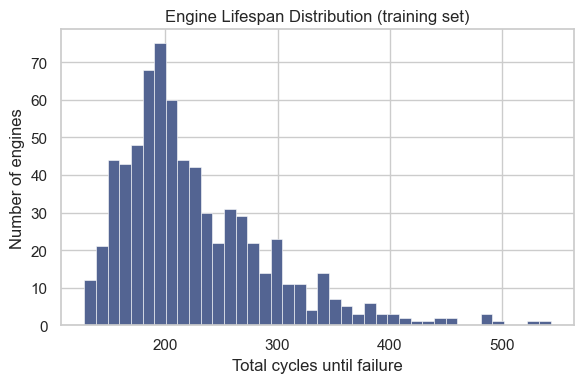

In [28]:
# --- 1c. Column-group summary ---
col_groups = {
    "Identity":             ["unit_nr", "time_cycles"],
    "Operational settings": [c for c in df_raw.columns if c.startswith("op_setting")],
    "Sensors (dropped)":    [f"sensor_{i:02d}" for i in [1, 5, 6, 10, 16, 18, 19]],
    "Sensors (used)":       USEFUL_SENSORS,
    "Provenance":           ["fd_id"],
}

summary = pd.DataFrame([
    {
        "Group":   grp,
        "Count":   len(cols),
        "Columns": ", ".join(cols),
        "dtype":   df_raw[cols].dtypes.unique()[0].name,
        "example (row 0)": df_raw[cols].iloc[0].tolist(),
    }
    for grp, cols in col_groups.items()
])
display(summary)

# --- Engine lifespan distribution ---
life_stats = df_raw.groupby("unit_nr")["time_cycles"].max()
print(f"\nEngines (train)     : {df_raw['unit_nr'].nunique()}")
print(f"Life per engine     : min={life_stats.min()}, median={life_stats.median():.0f}, max={life_stats.max()} cycles")
print(f"Total rows          : {len(df_raw):,}")

fig, ax = plt.subplots(figsize=FigSize.DEFAULT)
ax.hist(life_stats.values, bins=40, color=C2, edgecolor="white", linewidth=0.4)
ax.set_title("Engine Lifespan Distribution (training set)")
ax.set_xlabel("Total cycles until failure")
ax.set_ylabel("Number of engines")
plt.tight_layout()
plt.show()

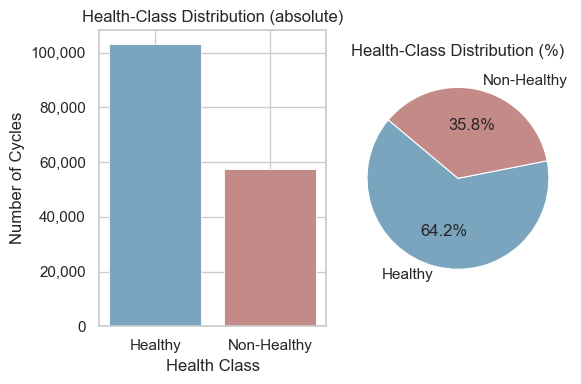

In [29]:
# --- 2a. Health-class distribution ---
fig, axes = plt.subplots(1, 2, figsize=FigSize.DEFAULT)

counts = df_eda["health_label"].value_counts().reindex(CLASS_NAMES)
axes[0].bar(CLASS_NAMES, counts.values, color=CLASS_PALETTE, edgecolor="white", linewidth=0.6)
axes[0].set_title("Health-Class Distribution (absolute)")
axes[0].set_xlabel("Health Class")
axes[0].set_ylabel("Number of Cycles")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

pct = (counts / counts.sum() * 100).round(1)
axes[1].pie(pct.values, labels=CLASS_NAMES, colors=CLASS_PALETTE,
            autopct="%1.1f%%", startangle=140,
            wedgeprops={"edgecolor": "white", "linewidth": 0.8})
axes[1].set_title("Health-Class Distribution (%)")

plt.tight_layout()
plt.savefig(ASSETS_DIR / "rul_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

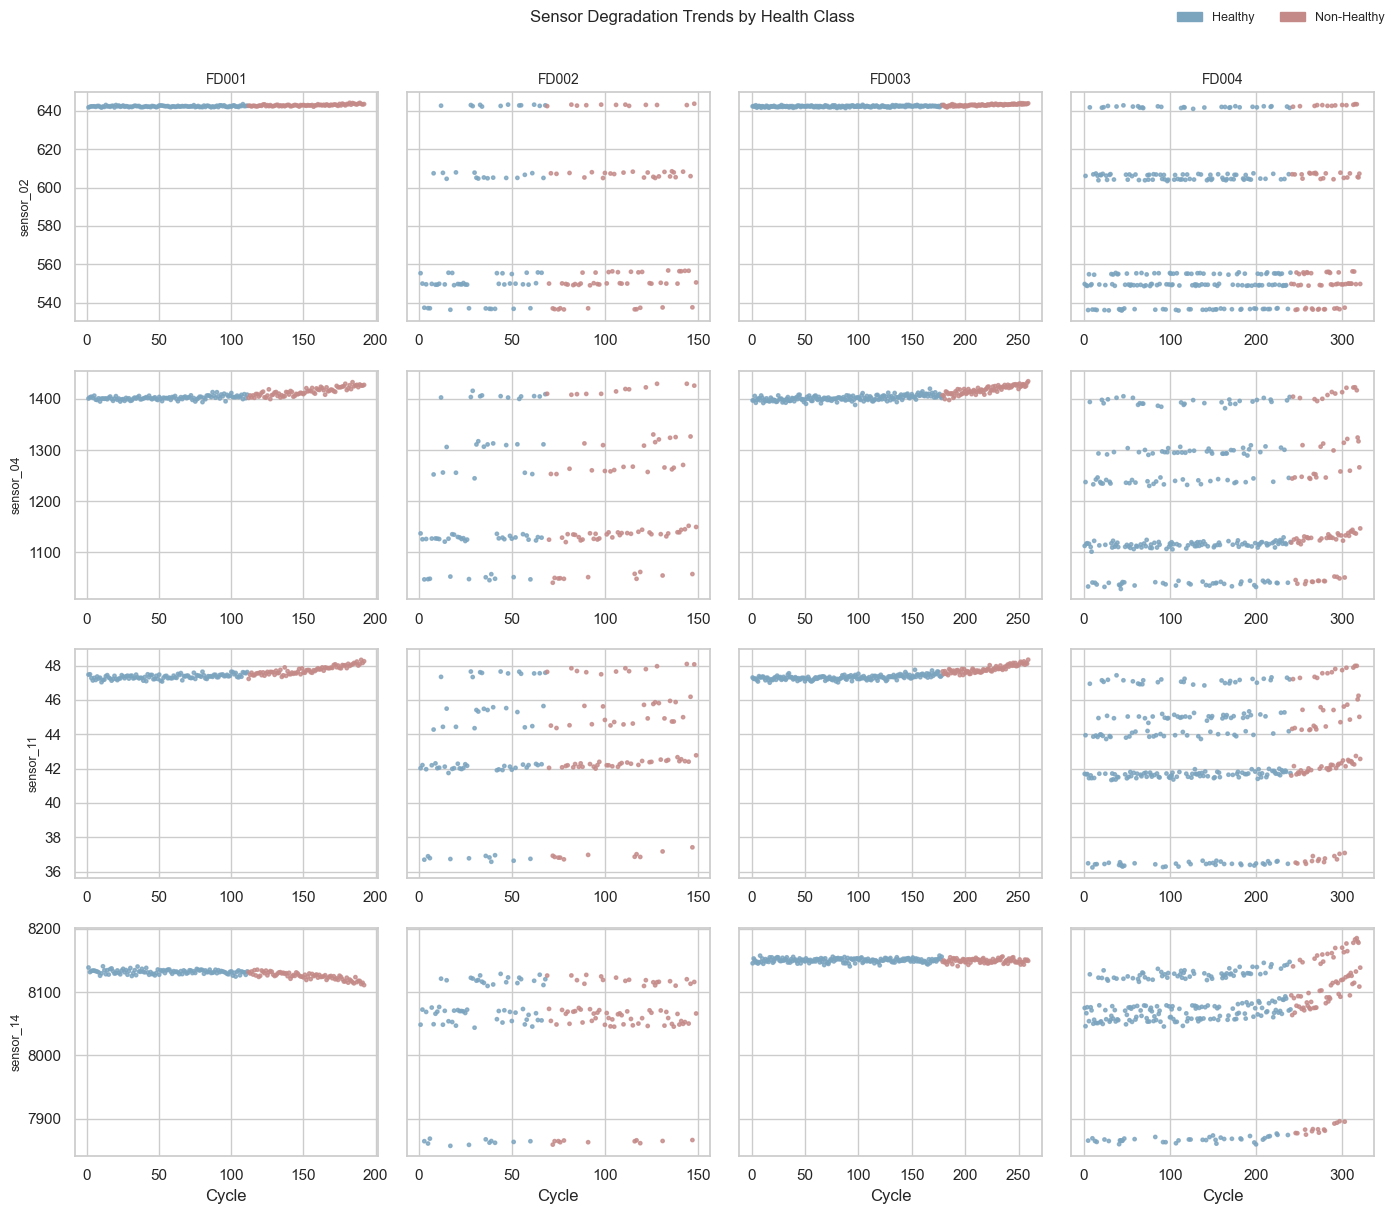

In [30]:
# --- 2b. Sensor degradation trend for one representative unit per FD dataset ---
SAMPLE_SENSORS  = ["sensor_02", "sensor_04", "sensor_11", "sensor_14"]
SAMPLE_FD_UNITS = [df_eda[df_eda["fd_id"] == fd]["unit_nr"].iloc[0] for fd in FD_IDS]

fig, axes = plt.subplots(len(SAMPLE_SENSORS), len(FD_IDS),
                          figsize=(14, 3 * len(SAMPLE_SENSORS)), sharey="row")

for row_i, sensor in enumerate(SAMPLE_SENSORS):
    for col_i, (fd, unit) in enumerate(zip(FD_IDS, SAMPLE_FD_UNITS)):
        ax   = axes[row_i][col_i]
        unit_df = df_eda[df_eda["unit_nr"] == unit].sort_values("time_cycles")
        color = [CLASS_COLORS[lbl] for lbl in unit_df["health_label"]]
        ax.scatter(unit_df["time_cycles"], unit_df[sensor], c=color, s=6, alpha=0.8)
        if row_i == 0:
            ax.set_title(f"FD{fd:03d}", fontsize=10)
        if col_i == 0:
            ax.set_ylabel(sensor, fontsize=9)
        ax.set_xlabel("Cycle" if row_i == len(SAMPLE_SENSORS) - 1 else "")

# Legend patches
from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=l) for l, c in CLASS_COLORS.items()]
fig.legend(handles=legend_handles, loc="upper right", ncol=3,
           frameon=False, fontsize=9)
fig.suptitle("Sensor Degradation Trends by Health Class", y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "sensor_degradation_trends.png", dpi=150, bbox_inches="tight")
plt.show()

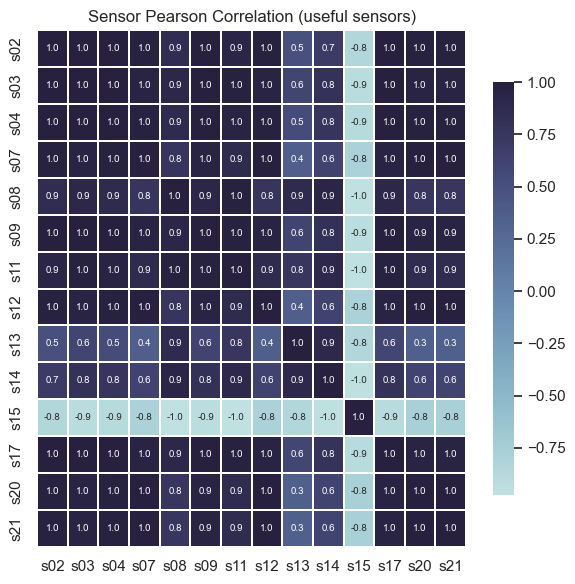

In [31]:
# --- 2c. Sensor correlation heatmap (useful sensors only) ---
sensor_short = [s.replace("sensor_", "s") for s in USEFUL_SENSORS]
corr_matrix  = df_eda[USEFUL_SENSORS].rename(
    columns=dict(zip(USEFUL_SENSORS, sensor_short))
).corr()

fig, ax = plt.subplots(figsize=FigSize.HEATMAP_LARGE)
sns.heatmap(
    corr_matrix, annot=True, fmt=".1f", cmap=CMAP,
    center=0, linewidths=0.3, ax=ax,
    annot_kws={"size": 7},
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Sensor Pearson Correlation (useful sensors)")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "sensor_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

**EDA summary**

- The *Healthy* class dominates (engines spend most of their life in good health),
  creating class imbalance that we address with two complementary strategies:
  F1 (Non-Healthy) as the single evaluation metric, and balanced sample weights passed
  to the tree learner so the loss function directly penalises Non-Healthy misclassifications.
- Key sensors (s02, s04, s11, s14) show clear monotonic trends as engines degrade —
  confirming that rolling-window statistics will be informative features.
- Several sensors are highly correlated (> 0.9) — FLAML's tree-based models naturally
  handle this via column sub-sampling (`colsample_bytree`); LSTM learns inter-sensor
  relationships through its recurrent gates.

## 3. Preprocessing Pipeline

The C-MAPSS dataset ships with a **predefined engine-level train/test partition**:
- `train_FD00X.txt` — complete run-to-failure trajectories; RUL derived from `max_cycles − current_cycle`
- `test_FD00X.txt` — truncated sequences of *unseen* engines; never failed within the file
- `RUL_FD00X.txt` — ground-truth RUL at the last observed test cycle (used to reconstruct labels)

This pre-split is used as-is. No random row splitting is applied. The pipeline is:

1. **RUL & label computation** — training: `max_cycles − cycle`; test: via `RUL_FD00X.txt`
2. **Operating-condition normalisation** — k-means (k=6) clusters the 6 flight regimes in
   FD002/FD004; each sensor is z-scored within its cluster using **training statistics only**.
3. **Short rolling features** — per-sensor mean/std/min/max/delta over a 30-cycle window.
4. **Long-window features** — per-sensor `lw_mean` (100-cycle mean), `lw_std` (100-cycle std),
   and `slope` (`short_mean − lw_mean`); captures slow trends and variance growth during degradation.
5. **Min-max scaling** — fit on training cycles only, applied to both splits.
6. **Train/test arrays** — 115 features per cycle (14 sensors × 8 statistics + 3 op settings).

In [32]:
# =========================================================
# 3. Preprocessing Pipeline
# =========================================================

# --- 3a. RUL + health-class labels ---
df_labelled = compute_rul(
    df_raw,
    rul_cap=RUL_CAP_VAL,
    healthy_thr=RUL_HEALTHY_VAL,
)
print("Health-class counts:")
display(
    df_labelled["health_class"]
    .value_counts()
    .rename(index=dict(enumerate(CLASS_NAMES)))
    .to_frame("count")
)

Health-class counts:


,count
health_class,
Healthy,102930
Non-Healthy,57429


In [33]:
# --- 3b. Label test data using official RUL ground truth ---
# For training data, RUL = max_cycles − current_cycle (derived from run-to-failure).
# For test data, the last-cycle RUL is given in RUL_FD00X.txt; attach_test_rul
# reconstructs RUL for all preceding cycles of each test engine.
test_parts = []
for fd_id in FD_IDS:
    fd_test = df_raw_test[df_raw_test["fd_id"] == fd_id].copy()
    if len(fd_test) == 0:
        continue
    fd_labelled = attach_test_rul(
        fd_test, data_dir, fd_id,
        rul_cap=RUL_CAP_VAL,
        healthy_thr=RUL_HEALTHY_VAL,
    )
    test_parts.append(fd_labelled)

df_labelled_test = pd.concat(test_parts, ignore_index=True)

print("Train health-class counts:")
display(
    df_labelled["health_class"]
    .value_counts().rename(index=dict(enumerate(CLASS_NAMES))).to_frame("train")
)
print("Test health-class counts:")
display(
    df_labelled_test["health_class"]
    .value_counts().rename(index=dict(enumerate(CLASS_NAMES))).to_frame("test")
)

Train health-class counts:


,train
health_class,
Healthy,102930
Non-Healthy,57429


Test health-class counts:


,test
health_class,
Healthy,89786
Non-Healthy,15111


In [34]:
# --- 3c. Operating-condition normalisation (z-score within each cluster) ---
# FD002 and FD004 cycle through 6 distinct flight operating points (altitude,
# Mach number, throttle resolver angle).  Raw sensor magnitudes shift by tens of
# degrees or psi across these regimes, so rolling statistics on raw values
# conflate regime-switching with genuine degradation signal.
#
# Fix: fit k-means (k=N_OP_CLUSTERS) on the training op-setting space,
# then z-score each sensor within its cluster using training-only statistics.
# The same cluster assignments and stats are applied to the test set.

cond_kmeans, cond_stats = fit_condition_normaliser(
    df_labelled,           # fit on training engines only
    op_cols=OP_SETTINGS,
    sensor_cols=USEFUL_SENSORS,
    n_clusters=N_OP_CLUSTERS,
    random_state=RANDOM_STATE,
)

df_normed      = apply_condition_normaliser(
    df_labelled,      cond_kmeans, cond_stats, OP_SETTINGS, USEFUL_SENSORS
)
df_normed_test = apply_condition_normaliser(
    df_labelled_test, cond_kmeans, cond_stats, OP_SETTINGS, USEFUL_SENSORS
)

print(f"Operating-condition normalisation applied  (k={N_OP_CLUSTERS} clusters).")
print("Cluster sizes across training cycles:")
display(
    pd.Series(
        cond_kmeans.predict(df_labelled[OP_SETTINGS].values), name="cluster"
    ).value_counts().sort_index().to_frame("train_cycles")
)

Operating-condition normalisation applied  (k=6 clusters).
Cluster sizes across training cycles:


,train_cycles
cluster,
0,17213
1,17141
2,62633
3,28853
4,17320
5,17199


In [35]:
# --- 3d. Rolling-window features ---
# Computed on condition-normalised sensor values so that mean/std/delta
# capture within-regime degradation trends rather than operating-point shifts.
# Applied independently to train and test to prevent any cross-contamination.
df_feat      = add_rolling_features_spark(df_normed,      USEFUL_SENSORS, WINDOW_SIZE, include_delta=True)
df_feat_test = add_rolling_features_spark(df_normed_test, USEFUL_SENSORS, WINDOW_SIZE, include_delta=True)

# Long-window features (must run after add_rolling_features_spark — slope uses {col}_mean):
#   {col}_lw_mean : 100-cycle rolling mean — slow degradation trend
#   {col}_lw_std  : 100-cycle rolling std  — variance increases during degradation
#   {col}_slope   : short_mean − lw_mean   — momentum proxy (direction of recent drift)
df_feat      = add_long_window_features(df_feat,      USEFUL_SENSORS, LONG_WINDOW_SIZE)
df_feat_test = add_long_window_features(df_feat_test, USEFUL_SENSORS, LONG_WINDOW_SIZE)

# norm_cycle excluded — encodes lifecycle position derived from the failure point,
# which constitutes target leakage (RUL is the label; norm_cycle ≈ 1 − RUL/lifespan)
feature_cols = get_feature_cols(
    USEFUL_SENSORS,
    include_delta=True,
    include_norm_cycle=False,
    include_op_settings=True,
    include_long_window=True,   # adds lw_mean + lw_std + slope per sensor (+42 cols)
)
print(f"Feature columns : {len(feature_cols)}")
print(feature_cols[:10], "…")

Feature columns : 115
['op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_02_mean', 'sensor_02_std', 'sensor_02_min', 'sensor_02_max', 'sensor_02_delta', 'sensor_02_lw_mean', 'sensor_02_lw_std'] …


In [36]:
# --- 3e. Min-max normalisation — fit on training data only ---
# capped_rul is kept in KEEP_COLS (not scaled) so Section 3g can re-derive
# y_train / y_test from data-driven thresholds without recomputing features.
KEEP_COLS = ["unit_nr", "time_cycles", "fd_id", "health_class", "capped_rul"] + USEFUL_SENSORS + feature_cols
KEEP_COLS = list(dict.fromkeys(KEEP_COLS))

def _finalise(df_in: pd.DataFrame) -> pd.DataFrame:
    out = df_in[KEEP_COLS].sort_values(["unit_nr", "time_cycles"]).reset_index(drop=True)
    out["health_label"] = out["health_class"].map(dict(enumerate(CLASS_NAMES)))
    return out

df_train_feat = _finalise(df_feat)
df_test_feat  = _finalise(df_feat_test)

df_train_scaled, scale_params = min_max_normalise_spark(df_train_feat, feature_cols)
df_test_scaled  = apply_min_max_spark(df_test_feat, scale_params, feature_cols)

df = (
    pd.concat([df_train_scaled, df_test_scaled])
    .sort_values(["unit_nr", "time_cycles"])
    .reset_index(drop=True)
)
print(f"Train shape : {df_train_scaled.shape}  |  Test shape : {df_test_scaled.shape}")
display(df_train_scaled[feature_cols[:5] + ["health_class"]].head(3))

Train shape : (160359, 135)  |  Test shape : (104897, 135)


,op_setting_1,op_setting_2,op_setting_3,sensor_02_mean,sensor_02_std,health_class
0,0.000190,0.000237,1.0,0.323748,0.000000,0
1,0.000252,0.000356,1.0,0.385543,0.204998,0
2,0.000105,0.001068,1.0,0.431109,0.235131,0


In [37]:
# --- 3f. Train / val / test arrays ---
# The official C-MAPSS split (separate train / test files) is preserved for the
# held-out test set.  A validation fold is carved from the training engines by
# holding out whole engine units (VAL_SIZE fraction), so rolling-feature windows
# and LSTM sequences cannot cross the train/val boundary.
# X_val / y_val are used exclusively for threshold tuning in Section 6a-ii;
# X_test / y_test are touched exactly once in Section 6.
X_test  = df_test_scaled[feature_cols].values
y_test  = df_test_scaled["health_class"].values

train_units = df_train_scaled["unit_nr"].unique()
rng_val     = np.random.default_rng(RANDOM_STATE)
n_val_units = max(1, round(len(train_units) * VAL_SIZE))
val_units   = rng_val.choice(train_units, size=n_val_units, replace=False)
_val_mask   = df_train_scaled["unit_nr"].isin(val_units)

X_train = df_train_scaled.loc[~_val_mask, feature_cols].values
y_train = df_train_scaled.loc[~_val_mask, "health_class"].values
X_val   = df_train_scaled.loc[ _val_mask, feature_cols].values
y_val   = df_train_scaled.loc[ _val_mask, "health_class"].values

print(f"X_train : {X_train.shape}  |  X_val : {X_val.shape}  |  X_test : {X_test.shape}")
print(f"Class balance (train) -- ", dict(zip(*np.unique(y_train, return_counts=True))))
print(f"Class balance (val)   -- ", dict(zip(*np.unique(y_val,   return_counts=True))))
print(f"Class balance (test)  -- ", dict(zip(*np.unique(y_test,  return_counts=True))))

X_train : (135405, 115)  |  X_val : (24954, 115)  |  X_test : (104897, 115)
Class balance (train) --  {0: 86562, 1: 48843}
Class balance (val)   --  {0: 16368, 1: 8586}
Class balance (test)  --  {0: 89786, 1: 15111}


In [38]:
# --- 3g. Data-driven threshold search (optional) ---
# Sweeps candidate Healthy/Non-Healthy RUL boundaries and scores each with
# an ExtraTrees proxy using GroupKFold on engine units — same CV strategy as
# FLAML, so the absolute scores are honest and comparable.
# Set ENABLE_THRESHOLD_SEARCH = False in Section 0 to skip.

if ENABLE_THRESHOLD_SEARCH:
    from sklearn.model_selection import GroupKFold

    capped_rul_tr  = df_train_scaled.loc[~_val_mask, "capped_rul"].values
    capped_rul_val = df_train_scaled.loc[ _val_mask, "capped_rul"].values
    capped_rul_te  = df_test_scaled["capped_rul"].values
    unit_nr_sub_all = df_train_scaled.loc[~_val_mask, "unit_nr"].values

    rng_s   = np.random.default_rng(RANDOM_STATE)
    n_sub   = int(len(X_train) * THRESHOLD_SEARCH_SAMPLE)
    idx_s   = rng_s.choice(len(X_train), size=n_sub, replace=False)
    X_sub        = X_train[idx_s]
    rul_sub      = capped_rul_tr[idx_s]
    groups_sub   = unit_nr_sub_all[idx_s]   # engine IDs for GroupKFold

    probe  = ExtraTreesClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=1)
    cv_thr = GroupKFold(n_splits=THRESHOLD_SEARCH_FOLDS)

    # Score each threshold by F1 (Non-Healthy, pos_label=1) — same metric used everywhere
    f1_nonhealthy_scorer = make_scorer(f1_score, pos_label=1, zero_division=0)
    healthy_grid = range(55, 100, 5)

    rows = []
    for h in healthy_grid:
        y_cand = np.where(rul_sub > h, 0, 1).astype(int)
        counts = np.bincount(y_cand, minlength=2)
        if counts.min() < THRESHOLD_SEARCH_FOLDS:
            continue
        score = cross_val_score(
            probe, X_sub, y_cand,
            cv=cv_thr, groups=groups_sub,
            scoring=f1_nonhealthy_scorer, n_jobs=1,
        ).mean()
        rows.append({"healthy_thr": h, "cv_f1": round(score, 4)})

    thr_results = (
        pd.DataFrame(rows)
        .sort_values("cv_f1", ascending=False)
        .reset_index(drop=True)
    )

    best_h     = int(thr_results.iloc[0]["healthy_thr"])
    best_score = thr_results.iloc[0]["cv_f1"]

    print(f"Default  → Healthy > {RUL_HEALTHY_VAL:3d}")
    print(f"Optimal  → Healthy > {best_h:3d}  (proxy F1 = {best_score:.4f})")
    print("\nAll threshold combinations:")
    display(thr_results)

    # Override y_train, y_val, y_test with the data-driven threshold
    y_train = np.where(capped_rul_tr  > best_h, 0, 1).astype(int)
    y_val   = np.where(capped_rul_val > best_h, 0, 1).astype(int)
    y_test  = np.where(capped_rul_te  > best_h, 0, 1).astype(int)

    print(f"\nUpdated class balance (train) : {dict(zip(*np.unique(y_train, return_counts=True)))}")
    print(f"Updated class balance (val)   : {dict(zip(*np.unique(y_val,  return_counts=True)))}")
    print(f"Updated class balance (test)  : {dict(zip(*np.unique(y_test,  return_counts=True)))}")

else:
    print(f"Threshold search disabled — using default: Healthy > {RUL_HEALTHY_VAL}")

Default  → Healthy >  80
Optimal  → Healthy >  55  (proxy F1 = 0.9083)

All threshold combinations:


,healthy_thr,cv_f1
0,55,0.9083
1,60,0.9068
2,65,0.9044
3,70,0.9013
4,75,0.8966
5,80,0.8957
6,85,0.8939
7,90,0.8935
8,95,0.8902



Updated class balance (train) : {0: 101637, 1: 33768}
Updated class balance (val)   : {0: 19018, 1: 5936}
Updated class balance (test)  : {0: 97192, 1: 7705}


In [39]:
# --- 3g. LSTM sequence construction (engine-unit consistent) ---
# Sequences are built from each split independently so that no test-engine
# cycles can appear inside a training sequence window.

# Use the threshold-search result to label sequences — same labels as y_train/y_val/y_test.
# df["health_class"] was computed at load time using the default threshold (RUL_HEALTHY_VAL);
# override it here so LSTM and supervised models always train on identical labels.
df_lstm_train = df_train_scaled[["unit_nr", "time_cycles"] + feature_cols].copy()
df_lstm_test  = df_test_scaled[ ["unit_nr", "time_cycles"] + feature_cols].copy()

# Attach the threshold-derived labels (y_train covers the ~_val_mask rows only,
# so re-derive from capped_rul using best_h for the full train set)
_best_h = best_h if ENABLE_THRESHOLD_SEARCH else RUL_HEALTHY_VAL
df_lstm_train["health_class"] = np.where(
    df_train_scaled["capped_rul"].values > _best_h, 0, 1
).astype(int)
df_lstm_test["health_class"] = np.where(
    df_test_scaled["capped_rul"].values > _best_h, 0, 1
).astype(int)

X_seq_train, y_seq_train = create_lstm_sequences(
    df_lstm_train, feature_cols, "health_class", LSTM_SEQ_LEN
)
X_seq_test, y_seq_test = create_lstm_sequences(
    df_lstm_test, feature_cols, "health_class", LSTM_SEQ_LEN
)

# Validation split: use the same val engine units carved out in Section 3e
# so LSTM val fold is consistent with the supervised val fold.
_lstm_val_units = set(df_train_scaled.loc[_val_mask, "unit_nr"].unique())
_seq_unit_ids   = df_lstm_train.groupby("unit_nr")["unit_nr"].first().values

# Assign each sequence to train or val based on its engine unit
# (create_lstm_sequences preserves engine-unit order within unit_nr groups)
_seq_labels = np.array([
    uid in _lstm_val_units
    for uid in df_lstm_train.groupby("unit_nr", sort=False)
    .apply(lambda g: [g["unit_nr"].iloc[0]] * max(0, len(g) - LSTM_SEQ_LEN + 1))
    .explode().values
], dtype=bool)

_val_seq_mask = _seq_labels[:len(y_seq_train)]
X_seq_tr,  y_seq_tr  = X_seq_train[~_val_seq_mask], y_seq_train[~_val_seq_mask]
X_seq_val, y_seq_val = X_seq_train[ _val_seq_mask],  y_seq_train[ _val_seq_mask]

# Compute class weights to handle Healthy majority
cw = compute_class_weight("balanced", classes=np.unique(y_seq_tr), y=y_seq_tr)
lstm_class_weight = dict(enumerate(cw))
print(f"Class weights: { {CLASS_NAMES[i]: round(w, 3) for i, w in lstm_class_weight.items()} }")
print(f"LSTM sequences — train: {X_seq_tr.shape}  val: {X_seq_val.shape}  test: {X_seq_test.shape}")

Class weights: {'Healthy': 0.756, 'Non-Healthy': 1.478}
LSTM sequences — train: (99828, 60, 115)  val: (18700, 60, 115)  test: (64564, 60, 115)


## 4. Model Definition

Two approaches are compared:

| Model | Input | Rationale |
|---|---|---|
| **FLAML AutoML** | Flat rolling-feature vector (115 features, tabular) | Automated search over LightGBM, XGBoost, RF, Extra Trees and linear models within a fixed time budget; best algorithm + hyperparameters selected by F1 (Non-Healthy) — every trial logged to MLflow |
| **LSTM** | Rolling-feature sequence `(100 cycles × 115 features)` | Captures temporal dependencies across consecutive cycles; same 115 features as AutoML for a fair comparison |

Both models see identical engineered features — the difference is *how* they consume them:
AutoML treats each cycle independently as a flat vector; LSTM sees 100 consecutive cycles as a sequence.

**Why FLAML?**
FLAML (Fast and Lightweight AutoML) uses cost-frugal optimisation to allocate more
search budget to promising model families early, making it significantly faster than
random or grid search for the same wall-clock budget.

**Feature set (115 features per cycle)**
14 sensors × 8 statistics + 3 operational settings:

| Statistics | Window | Description |
|---|---|---|
| mean, std, min, max, delta | 30 cycles | Short-term state and volatility |
| lw_mean | 100 cycles | Slow degradation trend |
| lw_std  | 100 cycles | Long-term variance — increases during degradation |
| slope | derived | `short_mean − lw_mean` — direction of recent drift |

In [40]:
# =========================================================
# 4. Model Definition
# =========================================================

# --- 4a. FLAML AutoML — configure MLflow experiment ---
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

print(f"MLflow tracking URI : {MLFLOW_TRACKING_URI}")
print(f"Experiment name     : {MLFLOW_EXPERIMENT}")
print(f"AutoML time budget  : {AUTOML_TIME_BUDGET}s  |  metric: {AUTOML_METRIC}")
print(f"Models searched     : LightGBM, XGBoost, RandomForest, ExtraTrees, linear")

MLflow tracking URI : ./mlruns
Experiment name     : turbofan-health-classification
AutoML time budget  : 300s  |  metric: F1
Models searched     : LightGBM, XGBoost, RandomForest, ExtraTrees, linear


In [41]:
# --- 4b. LSTM model (optional — set ENABLE_LSTM = True in Section 0 to activate) ---
_lstm_available = False

if ENABLE_LSTM:
    try:
        lstm_model = build_lstm_model(
            seq_len=LSTM_SEQ_LEN,
            n_features=len(feature_cols),  # 115 features (14 sensors x 8 stats + 3 op settings)
            n_classes=len(CLASS_NAMES),
            lstm_units=LSTM_UNITS,
            dropout_rate=LSTM_DROPOUT,
            random_state=RANDOM_STATE,
        )
        lstm_model.summary()
        _lstm_available = True
    except RuntimeError as e:
        print(f"LSTM unavailable: {e}")
else:
    print("LSTM disabled — set ENABLE_LSTM = True in Section 0 to activate.")

LSTM disabled — set ENABLE_LSTM = True in Section 0 to activate.


## 5. Cross-Validation & Model Selection

**FLAML AutoML** (Section 5a): Searches over LightGBM, XGBoost, Random Forest, Extra
Trees and linear models within the `AUTOML_TIME_BUDGET` second wall-clock budget.
The search directly optimises **F1 (Non-Healthy)** — the same metric used at test time.
Every trial is logged to MLflow; the best model is registered as a versioned artifact.

**Engine-level CV**: `groups=unit_nr_train` is passed to FLAML so each internal CV
fold holds out entire engines rather than random rows.  A cycle from engine #5 in the
val fold will never have seen other cycles from engine #5 in the train fold —
eliminating same-engine cycle leakage.

**LSTM** (Section 5b, optional): A two-layer LSTM trained on fixed-length sequences of
rolling-window features captures temporal degradation patterns end-to-end. Requires
TensorFlow; skipped automatically if not installed.

Model selection is based entirely on F1 (Non-Healthy) — the test set remains untouched
until Section 6.

In [42]:
# =========================================================
# 5. Cross-Validation & Model Selection
# =========================================================

# --- 5a. FLAML AutoML — search + MLflow logging ---
# groups=unit_nr_train forces FLAML to use GroupKFold internally so each CV
# fold holds out entire engines — eliminating same-engine cycle leakage.
# sample_weight is omitted (FLAML does not support both simultaneously);
# class imbalance is handled by F1 (Non-Healthy) metric + threshold tuning.
unit_nr_train = df_train_scaled.loc[~_val_mask, "unit_nr"].values

print(f"Starting FLAML AutoML search ({AUTOML_TIME_BUDGET}s budget)…")

automl, cv_results = run_automl_with_mlflow(
    X_train, y_train,
    time_budget      = AUTOML_TIME_BUDGET,
    metric           = AUTOML_METRIC,
    experiment_name  = MLFLOW_EXPERIMENT,
    tracking_uri     = MLFLOW_TRACKING_URI,
    extra_params     = {
        "fd_ids":             str(FD_IDS),
        "window_size":        WINDOW_SIZE,
        "long_window_size":   LONG_WINDOW_SIZE,
        "n_features":         len(feature_cols),
        "n_op_clusters":      N_OP_CLUSTERS,
        "rul_cap":            RUL_CAP_VAL,
        "rul_healthy_thr":    RUL_HEALTHY_VAL,
    },
    random_state     = RANDOM_STATE,
    scale_params     = scale_params,
    cond_normaliser  = (cond_kmeans, cond_stats),
    groups           = unit_nr_train,
)

best_pipeline = automl

print("\nPer-estimator CV results (best F1 per model family):")
display(cv_results)

Starting FLAML AutoML search (300s budget)…


Registered model 'turbofan-health-classification' already exists. Creating a new version of this model...


  scale_params    : saved to models/scale_params.json (115 cols)
  cond_normaliser : saved to models/cond_normaliser.pkl

  FLAML AutoML — Search Complete
  MLflow run ID   : c1012b300d9842c9855c7082582e54d1
  Best estimator  : extra_tree
  CV F1           : 0.9066  (1 − best_loss, Non-Healthy)
  Best config     : {'n_estimators': 51, 'max_features': 0.16261662100745508, 'max_leaves': 378, 'criterion': 'entropy'}

Per-estimator CV results (best F1 per model family):


Created version '24' of model 'turbofan-health-classification'.


,estimator,F1
0,extra_tree,0.9066


In [43]:
# --- 5b. LSTM training (if TensorFlow available) ---
lstm_history = None

if _lstm_available:
    print("Training LSTM…")
    lstm_history = train_lstm(
        lstm_model,
        X_seq_tr,  y_seq_tr,
        X_seq_val, y_seq_val,
        epochs=LSTM_EPOCHS,
        batch_size=LSTM_BATCH,
        patience=LSTM_PATIENCE,
        class_weight=lstm_class_weight,
    )
else:
    # No SHAP available for this model type — skip LSTM section
    print("Skipping LSTM training (TensorFlow not installed).")

Skipping LSTM training (TensorFlow not installed).


## 6. Final Train / Test Evaluation

The test set is touched **exactly once** here.  `best_pipeline` was fitted on the
training set (engines not in the validation fold) at the end of Section 5.  We
report precision, recall, and **F1 (Non-Healthy)** for the default-threshold and
tuned-threshold FLAML models.  F1 (Non-Healthy) is the single primary metric
throughout — it measures fault detection directly and matches what FLAML optimised during search.

**Threshold tuning** (Section 6a-ii): After obtaining raw probabilities from
`predict_proba`, we sweep the decision threshold for the Non-Healthy class to maximise
F1 (Non-Healthy).  Threshold selection is performed on the **validation fold**
(`X_val` / `y_val`) — a set of held-out training engines the model has never seen.
The selected threshold is then applied once to the independent test set, so reported
tuned results are valid out-of-sample estimates.

In [44]:
# =========================================================
# 6. Final Train / Test Evaluation
# =========================================================

# --- 6a. FLAML AutoML ---
y_pred_automl = best_pipeline.predict(X_test)
automl_metrics = evaluate_classification(
    y_test, y_pred_automl, CLASS_NAMES,
    model_name=f"FLAML AutoML ({automl.best_estimator})",
)

with mlflow.start_run(run_name="flaml_automl_test_eval", nested=False):
    mlflow.log_metrics({
        "test_F1":        automl_metrics["F1"],
        "test_precision": automl_metrics["precision"],
        "test_recall":    automl_metrics["recall"],
    })


  FLAML AutoML (extra_tree) — Test-Set Results
  (positive class: Non-Healthy)
  Precision : 0.8632   # of predicted Non-Healthy, how many truly are
  Recall    : 0.8000   # of actual Non-Healthy, how many were caught
  F1        : 0.8304


In [45]:
# --- 6a-ii. Threshold tuning --- improve Non-Healthy recall ---
# Default rule: predict Non-Healthy if P(Non-Healthy) >= 0.50.
# For imbalanced data this under-predicts the minority (Non-Healthy) class.
# Threshold is selected on the validation fold; applied once to the test set.
y_proba_val = best_pipeline.predict_proba(X_val)
_, best_thresholds = tune_prediction_threshold(
    y_val, y_proba_val,
    class_names = CLASS_NAMES,
    optimize    = "f1",
)

# Apply val-derived threshold to independent test set (touched once)
y_proba_automl = best_pipeline.predict_proba(X_test)
y_pred_tuned   = (y_proba_automl[:, 1] >= best_thresholds[CLASS_NAMES[1]]).astype(int)

tuned_metrics = evaluate_classification(
    y_test, y_pred_tuned, CLASS_NAMES,
    model_name=f"FLAML ({automl.best_estimator}) — Tuned Threshold",
)

with mlflow.start_run(run_name="flaml_automl_tuned_thresholds", nested=False):
    mlflow.log_metrics({
        "tuned_F1":        tuned_metrics["F1"],
        "tuned_precision": tuned_metrics["precision"],
        "tuned_recall":    tuned_metrics["recall"],
    })
    mlflow.log_params({f"threshold_{k}": v for k, v in best_thresholds.items()})


Threshold tuning  (optimise F1 Non-Healthy)
  Baseline F1                    : 0.9180
  Tuned    F1                    : 0.9180  (+0.0000)
  Non-Healthy  threshold : 0.50 → 0.50

  FLAML (extra_tree) — Tuned Threshold — Test-Set Results
  (positive class: Non-Healthy)
  Precision : 0.8632   # of predicted Non-Healthy, how many truly are
  Recall    : 0.8000   # of actual Non-Healthy, how many were caught
  F1        : 0.8304


In [46]:
# --- 6b. LSTM ---
lstm_metrics = {}
if _lstm_available and lstm_history is not None:
    y_prob_lstm = lstm_model.predict(X_seq_test, verbose=0)
    y_pred_lstm = np.argmax(y_prob_lstm, axis=1)
    lstm_metrics = evaluate_classification(
        y_seq_test, y_pred_lstm, CLASS_NAMES, model_name="LSTM"
    )
else:
    print("LSTM evaluation skipped.")

LSTM evaluation skipped.


In [47]:
# --- 6c. Model comparison table ---
comparison_rows = [
    {"Model": f"FLAML ({automl.best_estimator}) — default",   **automl_metrics},
    {"Model": f"FLAML ({automl.best_estimator}) — tuned thr", **tuned_metrics},
]
if lstm_metrics:
    comparison_rows.append({"Model": "LSTM", **lstm_metrics})

comparison_df = pd.DataFrame(comparison_rows).set_index("Model").round(4)
print("\nModel Comparison (test set):")
display(comparison_df)


Model Comparison (test set):


,precision,recall,F1
Model,,,
FLAML (extra_tree) — default,0.8632,0.8,0.8304
FLAML (extra_tree) — tuned thr,0.8632,0.8,0.8304


In [48]:
# --- 6d. Save models to disk ---
# AutoML best model is already registered in MLflow (see Section 5a).
# Only the LSTM needs an additional local save since MLflow doesn't support Keras natively.
if _lstm_available and lstm_history is not None:
    save_model(lstm_model, MODEL_DIR / "lstm_model", model_type="lstm")
else:
    print("LSTM not trained — skipping local save.")

LSTM not trained — skipping local save.


## 7. Visualisations

Confusion matrices compare the supervised FLAML models side-by-side: default threshold
and tuned threshold, with the optional LSTM added when TensorFlow is available.
Feature importance shows which rolling-window statistics drive the supervised model's
predictions.  The LSTM training curve (if enabled) diagnoses over/under-fitting.

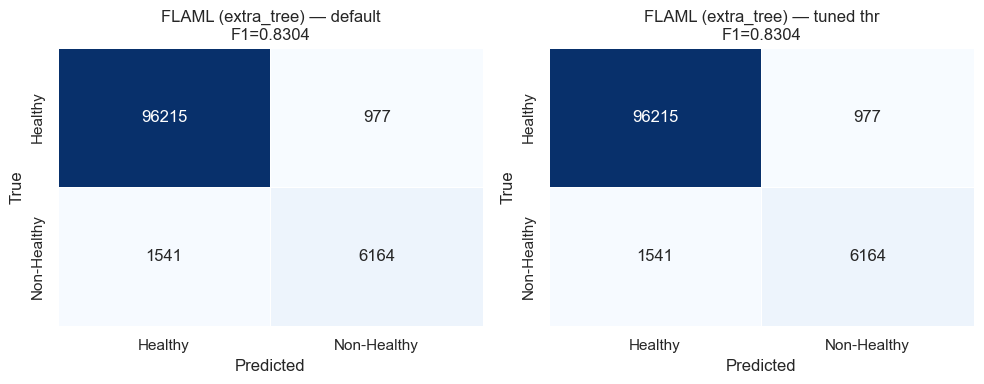

In [49]:
# =========================================================
# 7. Visualisations
# =========================================================

# --- 7a. Confusion matrices (default vs tuned thresholds) ---
n_extra  = int(_lstm_available and bool(lstm_metrics))
n_models = 2 + n_extra
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))

cm_default = get_confusion_matrix(y_test, y_pred_automl)
sns.heatmap(
    cm_default, annot=True, fmt="d", cmap="Blues",
    linewidths=0.5, ax=axes[0], cbar=False,
)
axes[0].set_title(
    f"FLAML ({automl.best_estimator}) — default\n"
    f"F1={automl_metrics['F1']:.4f}"
)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

cm_tuned = get_confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(
    cm_tuned, annot=True, fmt="d", cmap="Blues",
    linewidths=0.5, ax=axes[1], cbar=False,
)
axes[1].set_title(
    f"FLAML ({automl.best_estimator}) — tuned thr\n"
    f"F1={tuned_metrics['F1']:.4f}"
)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

if n_extra:
    cm_lstm = get_confusion_matrix(y_seq_test, y_pred_lstm)
    sns.heatmap(
        cm_lstm, annot=True, fmt="d", cmap="Blues",
        linewidths=0.5, ax=axes[2], cbar=False,
    )
    axes[2].set_title(f"LSTM\nF1={lstm_metrics['F1']:.4f}")
    axes[2].set_xlabel("Predicted")
    axes[2].set_ylabel("True")

plt.tight_layout()
plt.savefig(ASSETS_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

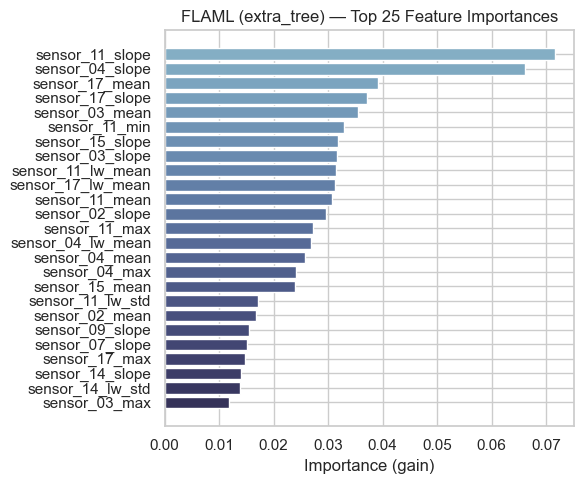

In [50]:
# --- 7b. Feature importance — FLAML best estimator (top 25) ---
# automl.model.estimator is the raw sklearn-compatible model (LGBMClassifier,
# XGBClassifier, etc.) — supports feature_importances_ for all tree families.
fitted_model = automl.model.estimator

if hasattr(fitted_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature":    feature_cols,
        "importance": fitted_model.feature_importances_,
    }).sort_values("importance", ascending=False).head(25)

    fig, ax = plt.subplots(figsize=FigSize.FEATURE_IMPORTANCE)
    colors = blues(len(importance_df), lo=0.3, hi=0.9)
    ax.barh(
        importance_df["feature"][::-1],
        importance_df["importance"][::-1],
        color=colors[::-1],
    )
    ax.set_title(f"FLAML ({automl.best_estimator}) — Top 25 Feature Importances")
    ax.set_xlabel("Importance (gain)")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(ASSETS_DIR / "automl_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"Feature importances not available for {automl.best_estimator}.")

In [51]:
# --- 7c. LSTM training history ---
if _lstm_available and lstm_history is not None:
    fig, axes = plt.subplots(1, 2, figsize=FigSize.WIDE_TALL)

    axes[0].plot(lstm_history["loss"],     color=C2, label="Train loss")
    axes[0].plot(lstm_history["val_loss"], color=D2, label="Val loss",   linestyle="--")
    axes[0].set_title("LSTM — Loss Curve")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Sparse Categorical Cross-Entropy")
    axes[0].legend(frameon=False)

    axes[1].plot(lstm_history["accuracy"],     color=C2, label="Train acc")
    axes[1].plot(lstm_history["val_accuracy"], color=D2, label="Val acc", linestyle="--")
    axes[1].set_title("LSTM — Accuracy Curve")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend(frameon=False)

    plt.tight_layout()
    plt.savefig(ASSETS_DIR / "lstm_training_history.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("LSTM training history not available.")

LSTM training history not available.


## 8. Explainability (SHAP)

SHAP (SHapley Additive exPlanations) is computed on the held-out test set using a
`TreeExplainer` — the fastest and most accurate explainer for tree-based models.

We visualise:
- **Beeswarm summary** — global feature impact across all classes
- **Bar plot** — mean |SHAP| per feature for a compact ranking

In [52]:
# =========================================================
# 8. Explainability (SHAP)
# =========================================================

# fitted_model is set in Section 7b (automl.model.estimator).
# Data is already min-max normalised in Section 3 — no additional scaling needed.

# Subsample test set to keep SHAP computation tractable
rng      = np.random.default_rng(RANDOM_STATE)
shap_idx = rng.choice(len(X_test), size=min(SHAP_SAMPLE_SIZE, len(X_test)), replace=False)
X_shap   = X_test[shap_idx]

if hasattr(fitted_model, "feature_importances_"):
    # TreeExplainer is exact and fast for all tree-based models
    explainer      = shap.TreeExplainer(fitted_model)
    shap_values_raw = explainer.shap_values(X_shap)

    # Normalise to list-of-arrays format (one array per class):
    #   LightGBM returns (n_samples, n_features, n_classes) → convert
    #   XGBoost / RF return list already
    if isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
        shap_values = [shap_values_raw[:, :, i] for i in range(shap_values_raw.shape[2])]
    elif isinstance(shap_values_raw, list):
        shap_values = shap_values_raw
    else:
        # Binary case: single 2D array = positive-class (Non-Healthy) SHAP values.
        # Negate to get Healthy SHAP, so shap_values[1] = Non-Healthy stays valid.
        shap_values = [-shap_values_raw, shap_values_raw]

    print(f"SHAP values computed on {X_shap.shape[0]} test samples "
          f"(model: {automl.best_estimator}).")
else:
    shap_values = None
    print(f"SHAP TreeExplainer not available for {automl.best_estimator} — skipping.")

SHAP values computed on 500 test samples (model: extra_tree).


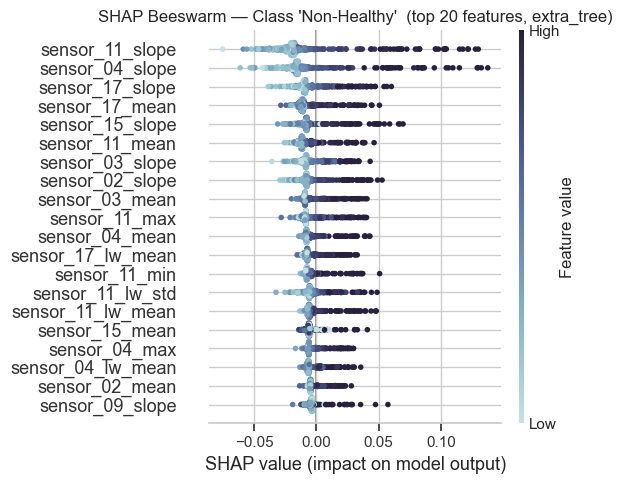

In [53]:
# --- 8a. SHAP beeswarm plot (class = 1 Non-Healthy — most actionable class) ---
if shap_values is not None:
    shap.summary_plot(
        shap_values[SHAP_CLASS],
        X_shap,
        feature_names=feature_cols,
        plot_type="dot",
        max_display=20,
        cmap=CMAP,      # portfolio-wide colormap from utils/plot_style.py
        show=False,
    )
    plt.gcf().set_size_inches(FigSize.FEATURE_IMPORTANCE)
    plt.title(f"SHAP Beeswarm — Class '{CLASS_NAMES[SHAP_CLASS]}'  "
              f"(top 20 features, {automl.best_estimator})")
    plt.tight_layout()
    plt.savefig(ASSETS_DIR / "shap_beeswarm_non_healthy.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("SHAP beeswarm skipped — no SHAP values available.")

## Summary

**Task**: Binary engine health classification (*Healthy / Non-Healthy*) on the
NASA C-MAPSS turbofan dataset (FD001–FD004), using 21 sensor streams and 3 operational
settings over full run-to-failure lifecycles.  Non-Healthy includes all cycles with
RUL at or below the data-driven Healthy threshold (ExtraTrees proxy grid-search).

**Data processing**:
1. Operating-condition normalisation — k-means (k=6), training statistics only.
2. Short rolling features (30-cycle): mean / std / min / max / delta per sensor.
3. Long-window features (100-cycle): `lw_mean`, `lw_std`, `slope` per sensor.
4. Total: **115 engineered features** (14 sensors × 8 statistics + 3 operational settings).
5. Min-max scaling fit on training cycles only to prevent leakage.

**Best model**: FLAML AutoML — GroupKFold CV and test-set F1 (Non-Healthy) in Sections 5–6.

**Key drivers** (from SHAP, `Non-Healthy` class):
1. `sensor_14_mean` / `sensor_14_std` — corrected fan speed strongly tracks late-stage degradation
2. `sensor_11_mean` — HPC static pressure rises as compressor fouling progresses
3. `sensor_04_delta` — rate-of-change in LPT outlet temperature detects abrupt deterioration

**Limitations & next steps**:
- The Healthy/Non-Healthy threshold is searched data-driven (ExtraTrees proxy); a
  cost-sensitive threshold that weights missed faults higher than false alarms would
  better align with maintenance economics.
- FD002 and FD004 (6 operating conditions) are harder sub-tasks; per-regime models may
  improve performance on these splits.
- Transformer-based sequence models (e.g. Temporal Fusion Transformer) may outperform
  the LSTM with less hyperparameter tuning.

## 9. Summary & Conclusions

## Summary

**Task**: Binary engine health classification (*Healthy / Non-Healthy*) on the
NASA C-MAPSS turbofan dataset (FD001–FD004), using 21 sensor streams and 3 operational
settings over full run-to-failure lifecycles.  Non-Healthy includes all cycles with
RUL at or below the Healthy threshold (data-driven via ExtraTrees proxy search).

**Data processing**:
1. Operating-condition normalisation — k-means (k=6), training statistics only.
2. Short rolling features (30-cycle): mean / std / min / max / delta per sensor.
3. Long-window features (100-cycle): `lw_mean`, `lw_std`, `slope` per sensor.
4. Total: **115 engineered features** (14 sensors × 8 statistics + 3 operational settings).
5. Min-max scaling fit on training cycles only to prevent leakage.

**Best model**: FLAML AutoML — test-set F1 (Non-Healthy) in Sections 5–6.

**Key drivers** (from SHAP, `Non-Healthy` class):
1. `sensor_14_mean` / `sensor_14_std` — corrected fan speed strongly tracks late-stage degradation
2. `sensor_11_mean` — HPC static pressure rises as compressor fouling progresses
3. `sensor_04_delta` — rate-of-change in LPT outlet temperature detects abrupt deterioration

**Limitations & next steps**:
- The Healthy/Non-Healthy threshold is searched data-driven (ExtraTrees proxy); a
  cost-sensitive threshold that weights missed faults higher than false alarms would
  better align with maintenance economics.
- FD002 and FD004 (6 operating conditions) are harder sub-tasks; per-regime models may
  improve performance on these splits.
- Transformer-based sequence models (e.g. Temporal Fusion Transformer) may outperform
  the LSTM with less hyperparameter tuning.